In [1]:
### Import Programmes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from sklearn.cluster import KMeans
from math import ceil
import time

### Robot Sample Locations

In [2]:
# Build robot data table 
ranges = pd.read_csv('range.csv')
locations = pd.read_csv('robot_locations.csv')

robots = (
    locations.merge(ranges, on='index', how='inner')
    .rename(columns={'index': 'robot_id'})
    [['robot_id', 'longitude', 'latitude', 'range']]
    .sort_values('robot_id')
    .reset_index(drop=True)
)

#robots.to_csv('robot_table.csv', index=False)
robots.head()

,robot_id,longitude,latitude,range
0,0,-120.240815,-79.238374,127.868274
1,1,-134.537839,-83.426214,87.246488
2,2,-105.282215,-84.681705,64.393799
3,3,-105.453243,-77.964007,100.815352
4,4,-168.816260,-86.934888,36.021544


Number of robots: 1072
Longitude range: -179.589 to 179.986
Latitude range: -89.992 to -63.988
Robot range: 10.743 to 173.899


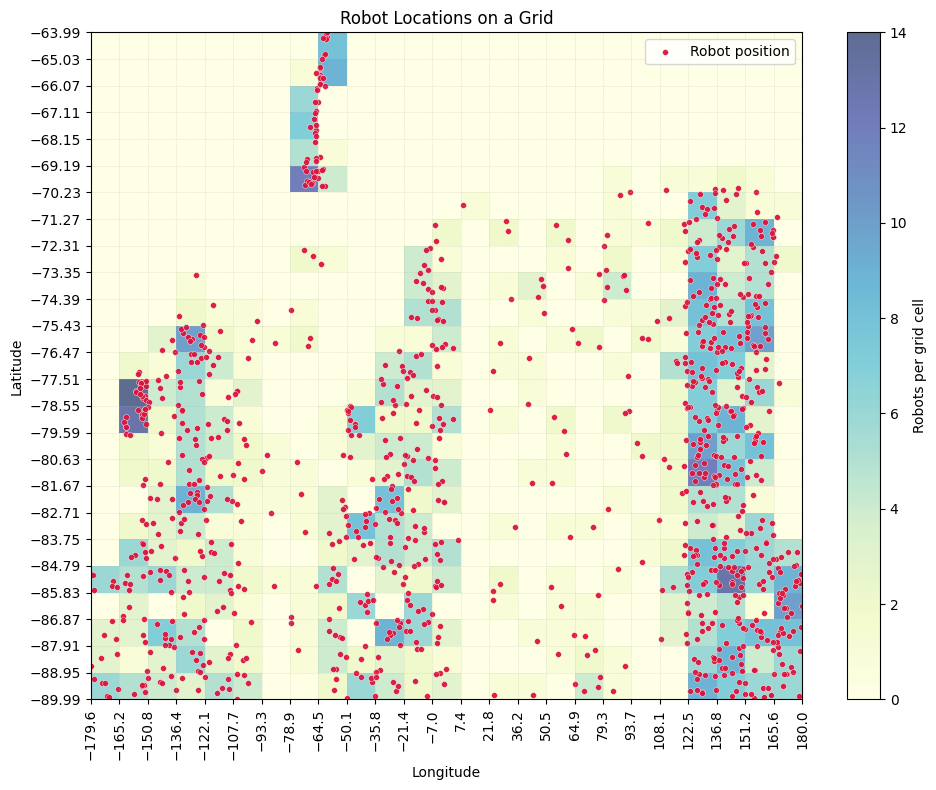

In [3]:
print(f'Number of robots: {len(robots)}')
print(f'Longitude range: {robots.longitude.min():.3f} to {robots.longitude.max():.3f}')
print(f'Latitude range: {robots.latitude.min():.3f} to {robots.latitude.max():.3f}')
print(f'Robot range: {robots["range"].min():.3f} to {robots["range"].max():.3f}')

grid_size = 25
lon_edges = np.linspace(robots['longitude'].min(), robots['longitude'].max(), grid_size + 1)
lat_edges = np.linspace(robots['latitude'].min(), robots['latitude'].max(), grid_size + 1)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.hist2d(
    robots['longitude'],
    robots['latitude'],
    bins=[lon_edges, lat_edges],
    cmap='YlGnBu',
    alpha=0.65
)
ax.scatter(
    robots['longitude'],
    robots['latitude'],
    s=18,
    c='crimson',
    edgecolors='white',
    linewidths=0.3,
    marker='o',
    alpha=0.95,
    label='Robot position'
)
plt.colorbar(heatmap[3], ax=ax, label='Robots per grid cell')
ax.set_title('Robot Locations on a Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks(lon_edges)
ax.set_yticks(lat_edges)
ax.tick_params(axis='x', labelrotation=90)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [4]:
# Random sample of robots

robots_subset = robots.sample(n=100, random_state=1).reset_index(drop=True).copy()

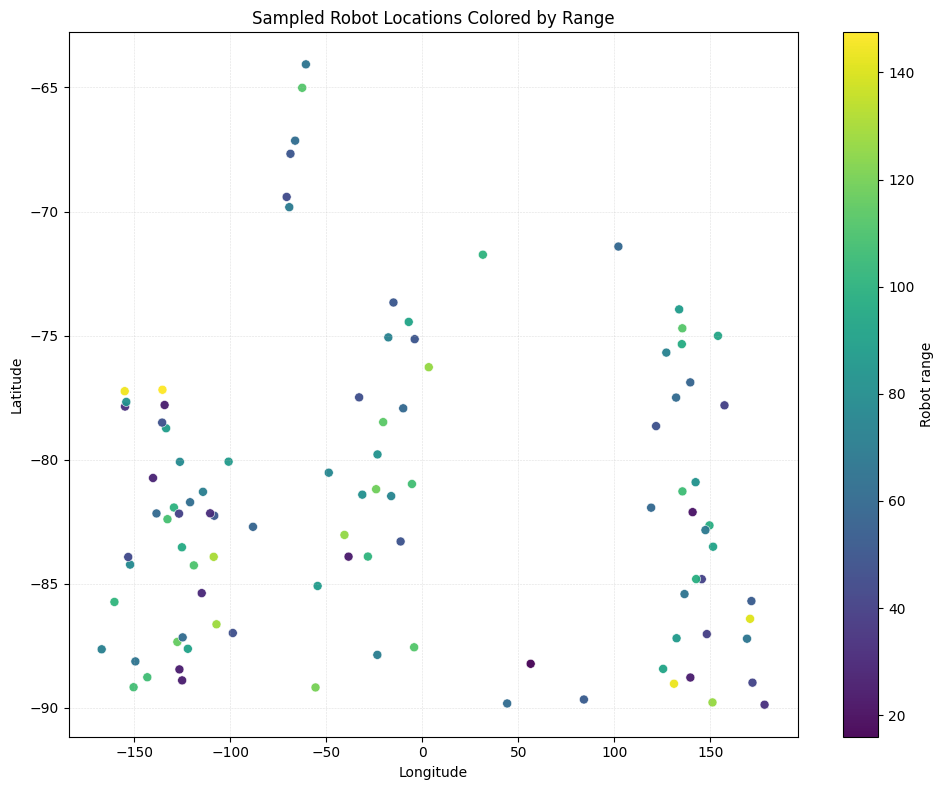

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    robots_subset['longitude'],
    robots_subset['latitude'],
    c=robots_subset['range'],
    cmap='viridis',
    s=42,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.95
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Robot range')
ax.set_title('Sampled Robot Locations Colored by Range')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.show()


### Candidate Locations

In [6]:
coords = robots_subset[["longitude", "latitude"]].to_numpy() # robot coordinates

# Higher weight for smaller-range robots
weights = 1.0 / np.maximum(robots_subset["range"].to_numpy(), 1e-6) # weights inversely proportional to range

candidate_rows = [] # stores candidate locations
candidate_id = 0 # to give each candidate a unique ID

# Generate candidate locations using KMeans clustering for group sizes 1 to 16
for s in range(1, 17):
    k = ceil(len(robots_subset) / s) # number of clusters based on group size s

    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(coords, sample_weight=weights)

    centers = km.cluster_centers_
    labels = km.labels_

    for cluster_idx in range(k):
        cluster_size = int(np.sum(labels == cluster_idx))
        center = centers[cluster_idx]

        candidate_rows.append({
            "candidate_id": candidate_id,
            "source_group_size": s,
            "cluster_size": cluster_size,
            "longitude": float(center[0]),
            "latitude": float(center[1])
        })
        candidate_id += 1

candidate_locations = pd.DataFrame(candidate_rows)

display(candidate_locations.head(20))
print("Number of candidate locations before deduplication:", len(candidate_locations))

,candidate_id,source_group_size,cluster_size,longitude,latitude
0,0,1,1,-16.249279,-81.470146
1,1,1,1,149.578195,-82.651637
2,2,1,1,-132.796099,-82.401487
3,3,1,1,56.426577,-88.229542
4,4,1,1,-69.331545,-69.824598
5,5,1,1,-114.954454,-85.381265
6,6,1,1,-149.516387,-88.133981
7,7,1,1,139.618091,-88.782956
8,8,1,1,171.426841,-85.701328
9,9,1,1,102.125240,-71.411317


Number of candidate locations before deduplication: 345


In [7]:
candidate_locations["lon_r"] = candidate_locations["longitude"].round(4)
candidate_locations["lat_r"] = candidate_locations["latitude"].round(4)

candidate_locations = (
    candidate_locations
    .drop_duplicates(subset=["lon_r", "lat_r"])
    .drop(columns=["lon_r", "lat_r"])
    .reset_index(drop=True)
)

candidate_locations["candidate_id"] = range(len(candidate_locations))


In [8]:
print("Number of candidate locations:", len(candidate_locations))
print("Candidates before deduplication:", len(pd.DataFrame(candidate_rows)))
print("Candidates after deduplication:", len(candidate_locations))
print(candidate_locations["source_group_size"].value_counts().sort_index())


Number of candidate locations: 203
Candidates before deduplication: 345
Candidates after deduplication: 203
source_group_size
1     100
2      28
3      18
4      12
5       9
6       8
7       7
8       4
9       1
10      5
12      2
13      4
15      5
Name: count, dtype: int64


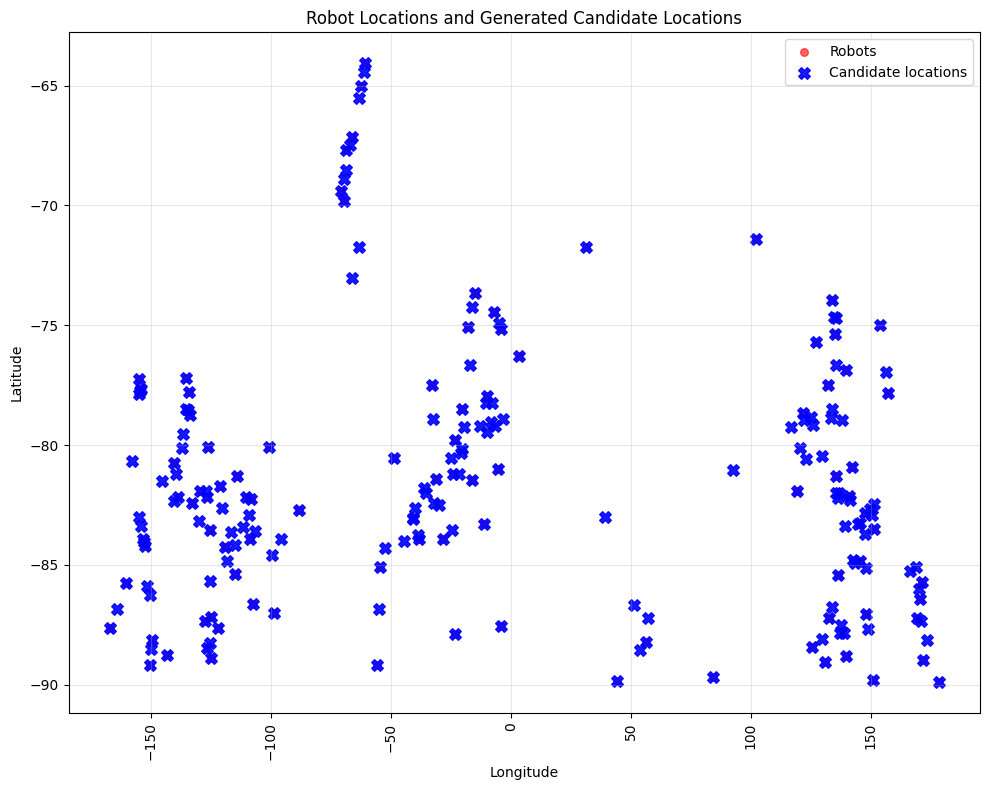

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot robot locations
ax.scatter(
    robots_subset["longitude"],
    robots_subset["latitude"],
    c="red",
    s=30,
    alpha=0.6,
    label="Robots"
)

# Plot candidate locations
ax.scatter(
    candidate_locations["longitude"],
    candidate_locations["latitude"],
    c="blue",
    s=70,
    marker="X",
    alpha=0.9,
    label="Candidate locations"
)

ax.set_title("Robot Locations and Generated Candidate Locations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


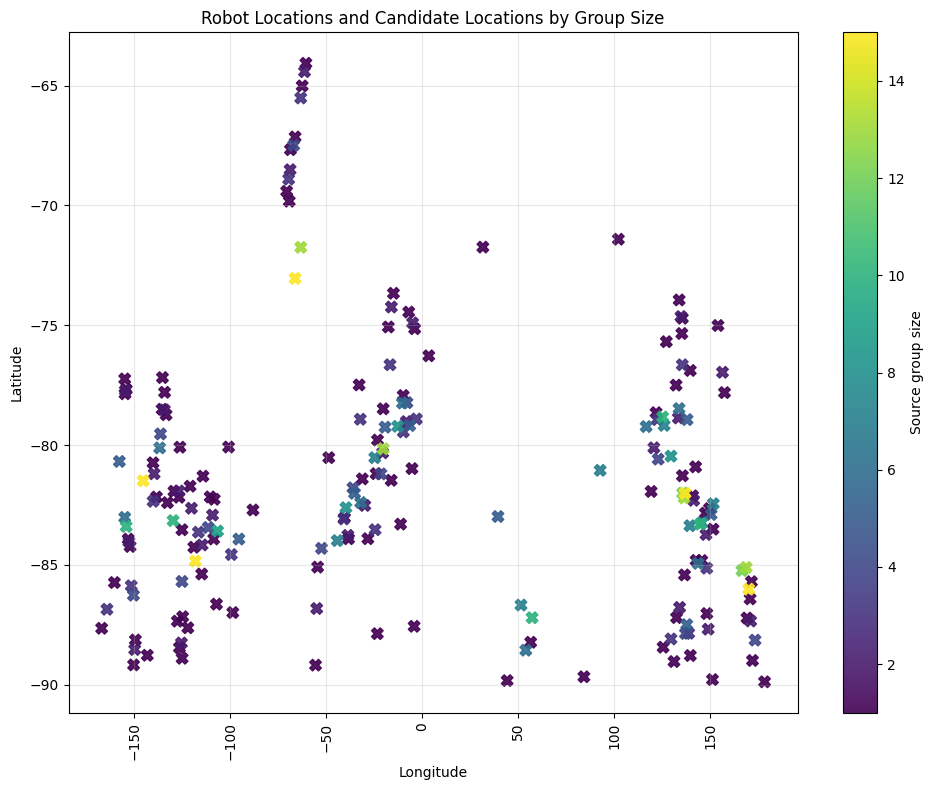

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    robots_subset["longitude"],
    robots_subset["latitude"],
    c="lightgray",
    s=25,
    alpha=0.6,
    label="Robots"
)

scatter = ax.scatter(
    candidate_locations["longitude"],
    candidate_locations["latitude"],
    c=candidate_locations["source_group_size"],
    cmap="viridis",
    s=70,
    marker="X",
    alpha=0.9
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Source group size")

ax.set_title("Robot Locations and Candidate Locations by Group Size")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Model

In [11]:
# Model parameters
planning_days = 365
m = 8
q = 2
c_b = 5000
c_h = 1000
c_m = 500
c_c = 0.42
lambda_ = 0.012
r_min = 10
r_max = 175

robots_model = robots_subset.copy().reset_index(drop=True)
stations_model = candidate_locations.copy().reset_index(drop=True)

distance_records = []

for _, robot in robots_model.iterrows():
    for _, station in stations_model.iterrows():
        d_ij = np.sqrt(
            (robot["longitude"] - station["longitude"]) ** 2 +
            (robot["latitude"] - station["latitude"]) ** 2
        )
        distance_records.append({
            "robot_id": int(robot["robot_id"]),
            "candidate_id": int(station["candidate_id"]),
            "d_ij": float(d_ij),
            "range": float(robot["range"])
        })

distance_table = pd.DataFrame(distance_records)
distance_table["unreachable"] = (distance_table["d_ij"] > distance_table["range"]).astype(int)

distance_table["unreachable"] = (distance_table["d_ij"] > distance_table["range"]).astype(int)

distance_table["assign_cost"] = planning_days * (
    c_c * (
        (r_max - distance_table["range"] + distance_table["d_ij"]) * (1 - distance_table["unreachable"])
        + (r_max - distance_table["range"]) * distance_table["unreachable"]
    )
    + c_h * distance_table["unreachable"]
)

print("Robots:", len(robots_model))
print("Candidate locations:", len(stations_model))
display(distance_table.head())
print("Robot-station pairs:", len(distance_table))



Robots: 100
Candidate locations: 203


,robot_id,candidate_id,d_ij,range,unreachable,assign_cost
0,120,0,91.158409,127.887414,0,21196.943615
1,120,1,256.870210,127.887414,1,372222.359480
2,120,2,25.884091,127.887414,0,11190.390667
3,120,3,163.695392,127.887414,1,372222.359480
4,120,4,41.489079,127.887414,0,13582.635330


Robot-station pairs: 20300


In [12]:
# Step 2: Greedy Construction Heuristic

# Sets and candidate IDs
robot_ids = robots_subset["robot_id"].astype(int).tolist()
candidate_ids = candidate_locations["candidate_id"].astype(int).tolist()

# Assignment-cost lookup: a_ij
# Mapping (robot_id, candidate_id) -> annual cost of assignment (disregarding station and charger costs)
assign_cost = {
    (int(row.robot_id), int(row.candidate_id)): float(row.assign_cost)
    for row in distance_table.itertuples(index=False)
}

# Maintain the heuristic state
unassigned_robots = set(robot_ids)  # all unnasigned robots
open_stations = []                  # candidate stations that have been opened
station_chargers = {}               # candidate_id -> number of chargers installed at that station
robot_assignment = {}               # robot_id -> candidate_id of assigned station

iteration = 0

while unassigned_robots:  # while there are still unnasigned robots
    iteration += 1        # next iteration
    best_choice = None    # create placeholder for best choice of???  
    best_avg_cost = float("inf")

    # loop over all non-opened candidate stations
    for j in candidate_ids: 
        if j in open_stations:  # if candidate station j is already open we skip the following step
            continue

        # Costs of assigning each currently unassigned robot to station j, sorted from cheapest to most expensive 
        robot_costs = sorted(
            [(i, assign_cost[(i, j)]) for i in unassigned_robots],
            key=lambda x: x[1]
        )


        for z in range(1, m + 1): # for each possible number of chargers 
            capacity = q * z  # compute robot capacity
            chosen = robot_costs[:capacity] # choose cheapest robots up to capacity

            if len(chosen) == 0: # if none chosen? whats the point?
                continue

            total_cost = c_b + c_m * z + sum(cost for _, cost in chosen)  # total cost of this  choice of chargers and assigned robots
            avg_cost = total_cost / len(chosen)  # average cost per assigned robot for this choice 

            # update best choice if this is the lowest average cost found so far
            if avg_cost < best_avg_cost: 
                best_avg_cost = avg_cost
                best_choice = {
                    "station": j,
                    "chargers": z,
                    "robots": [i for i, _ in chosen],
                    "total_cost": total_cost,
                    "avg_cost": avg_cost
                }
            
    if best_choice is None: # is this needed?
        raise RuntimeError("No feasible greedy station choice found.")

    # Open the chosen station
    chosen_station = best_choice["station"]
    chosen_chargers = best_choice["chargers"]
    chosen_robots = best_choice["robots"]

    open_stations.append(chosen_station) # add to list of open stations
    station_chargers[chosen_station] = chosen_chargers # add to mapping of station to station chargers

    # Assign robots to that station
    for i in chosen_robots:
        robot_assignment[i] = chosen_station # add to mapping of robot to assigned station
        unassigned_robots.remove(i)

    print(
        f"Iteration {iteration}: opened station {chosen_station} "
        f"with {chosen_chargers} chargers, assigned {len(chosen_robots)} robots, "
        f"{len(unassigned_robots)} robots remaining"
    )

print("Greedy construction completed.")
print("Opened stations:", open_stations)
print("Chargers per station:", station_chargers)



Iteration 1: opened station 96 with 1 chargers, assigned 2 robots, 98 robots remaining
Iteration 2: opened station 21 with 1 chargers, assigned 2 robots, 96 robots remaining
Iteration 3: opened station 26 with 1 chargers, assigned 2 robots, 94 robots remaining
Iteration 4: opened station 27 with 2 chargers, assigned 4 robots, 90 robots remaining
Iteration 5: opened station 79 with 2 chargers, assigned 4 robots, 86 robots remaining
Iteration 6: opened station 78 with 2 chargers, assigned 4 robots, 82 robots remaining
Iteration 7: opened station 43 with 1 chargers, assigned 2 robots, 80 robots remaining
Iteration 8: opened station 93 with 1 chargers, assigned 2 robots, 78 robots remaining
Iteration 9: opened station 90 with 1 chargers, assigned 2 robots, 76 robots remaining
Iteration 10: opened station 1 with 2 chargers, assigned 4 robots, 72 robots remaining
Iteration 11: opened station 88 with 2 chargers, assigned 4 robots, 68 robots remaining
Iteration 12: opened station 92 with 2 cha

### Results 1

In [13]:
# Build output tables from the greedy heuristic

heuristic_stations_df = pd.DataFrame([
    {
        "candidate_id": j,
        "chargers": station_chargers[j]
    }
    for j in open_stations
]).merge(
    candidate_locations[["candidate_id", "longitude", "latitude"]],
    on="candidate_id",
    how="left"
)

heuristic_assignments_df = pd.DataFrame([
    {
        "robot_id": i,
        "candidate_id": j,
        "assign_cost": assign_cost[(i, j)]
    }
    for i, j in robot_assignment.items()
]).merge(
    distance_table[["robot_id", "candidate_id", "d_ij", "range", "unreachable"]],
    on=["robot_id", "candidate_id"],
    how="left"
)

# Cost summary
heuristic_fixed_cost = sum(c_b + c_m * station_chargers[j] for j in open_stations)
heuristic_assignment_cost = heuristic_assignments_df["assign_cost"].sum()
heuristic_total_cost = heuristic_fixed_cost + heuristic_assignment_cost

print("Heuristic fixed cost:", heuristic_fixed_cost)
print("Heuristic assignment cost:", heuristic_assignment_cost)
print("Heuristic total cost:", heuristic_total_cost)

display(heuristic_stations_df)
display(heuristic_assignments_df.head(20))


Heuristic fixed cost: 195000
Heuristic assignment cost: 1997830.689423333
Heuristic total cost: 2192830.689423333


,candidate_id,chargers,longitude,latitude
0,96,1,-135.405585,-77.184375
1,21,1,-108.710986,-83.918674
2,26,1,131.093878,-89.033787
3,27,2,-24.096200,-81.193559
4,79,2,-129.419533,-81.930878
5,78,2,135.170869,-75.345502
6,43,1,-4.294199,-87.564641
7,93,1,-150.447159,-89.174222
8,90,1,-62.608154,-65.013654
9,1,2,149.578195,-82.651637


,robot_id,candidate_id,assign_cost,d_ij,range,unreachable
0,27,96,4218.735732,0.000000e+00,147.480524,0
1,205,96,7681.878637,1.966914e+01,144.559038,0
2,90,21,6877.586507,0.000000e+00,130.136422,0
3,120,21,7694.800966,3.081810e+00,127.887414,0
4,777,26,4791.731274,0.000000e+00,143.742784,0
5,651,26,10461.968727,2.006607e+01,126.821000,0
6,255,27,8703.420489,0.000000e+00,118.226220,0
7,383,27,10117.456243,1.659801e+01,125.600255,0
8,242,27,10181.445685,4.570625e+00,113.155454,0
9,453,27,11786.867315,2.786504e+01,125.977452,0


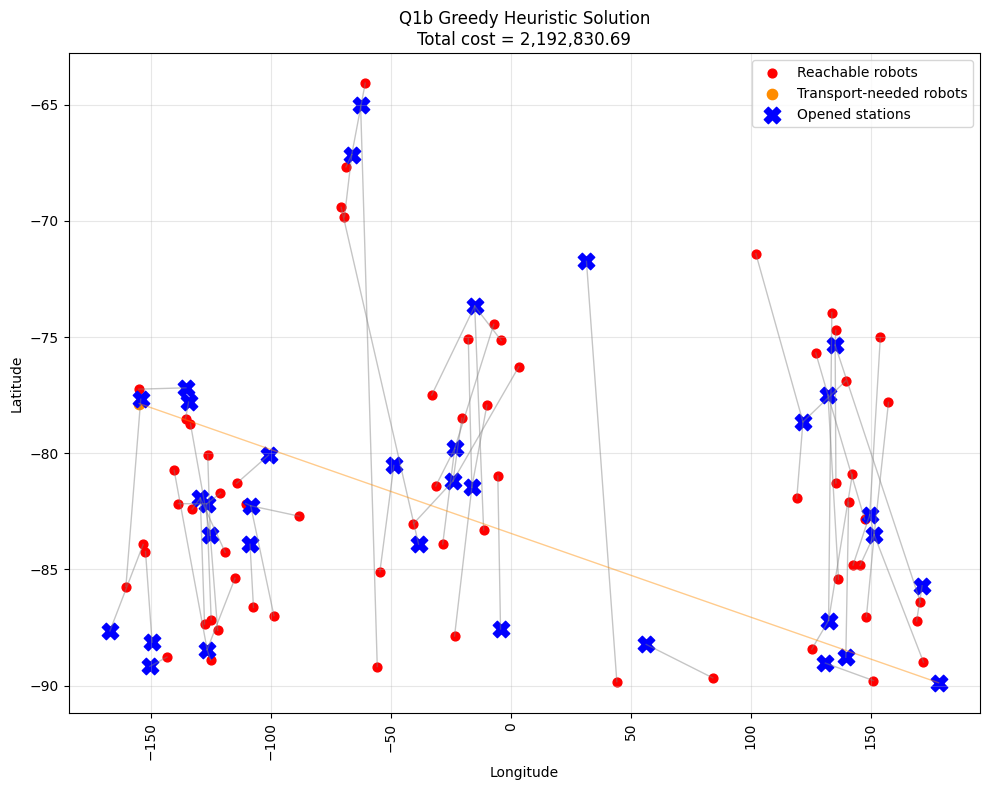

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

# Robots
transport_robot_ids = set(
    heuristic_assignments_df.loc[heuristic_assignments_df["unreachable"] == 1, "robot_id"]
)

reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

ax.scatter(
    reachable_robots["longitude"],
    reachable_robots["latitude"],
    c="red",
    s=40,
    label="Reachable robots"
)

if not transport_robots.empty:
    ax.scatter(
        transport_robots["longitude"],
        transport_robots["latitude"],
        c="darkorange",
        s=55,
        label="Transport-needed robots"
    )

# Opened stations
ax.scatter(
    heuristic_stations_df["longitude"],
    heuristic_stations_df["latitude"],
    c="blue",
    s=140,
    marker="X",
    label="Opened stations"
)

# Assignment lines
for _, row in heuristic_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = heuristic_stations_df[heuristic_stations_df["candidate_id"] == row["candidate_id"]].iloc[0]

    line_color = "darkorange" if row["unreachable"] == 1 else "gray"

    ax.plot(
        [robot["longitude"], station["longitude"]],
        [robot["latitude"], station["latitude"]],
        color=line_color,
        alpha=0.45,
        linewidth=1
    )

ax.set_title(f"Q1b Greedy Heuristic Solution\nTotal cost = {heuristic_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Optional Refinement

In [15]:
# Step 3: Improvement MILP over opened stations only

J_open = open_stations.copy()

range_lookup = robots_subset.set_index("robot_id")["range"].to_dict()

distance_lookup_open = {
    (int(row.robot_id), int(row.candidate_id)): float(row.d_ij)
    for row in distance_table.itertuples(index=False)
    if int(row.candidate_id) in J_open
}

unreachable_lookup_open = {
    (int(row.robot_id), int(row.candidate_id)): int(row.unreachable)
    for row in distance_table.itertuples(index=False)
    if int(row.candidate_id) in J_open
}


improve_model = pyo.ConcreteModel()

improve_model.I = pyo.Set(initialize=robot_ids)
improve_model.J = pyo.Set(initialize=J_open)

improve_model.r = pyo.Param(improve_model.I, initialize=range_lookup)
improve_model.d = pyo.Param(improve_model.I, improve_model.J, initialize=distance_lookup_open)
improve_model.unreachable = pyo.Param(
    improve_model.I, improve_model.J,
    initialize=unreachable_lookup_open,
    within=pyo.Binary
)


# Decision variables
improve_model.z = pyo.Var(improve_model.J, domain=pyo.NonNegativeIntegers)
improve_model.x = pyo.Var(improve_model.I, improve_model.J, domain=pyo.Binary)

# Each robot assigned to exactly one opened station
def assign_once_rule(model, i):
    return sum(model.x[i, j] for j in model.J) == 1
improve_model.assign_once = pyo.Constraint(improve_model.I, rule=assign_once_rule)

# Capacity at each opened station
def charger_capacity_rule(model, j):
    return sum(model.x[i, j] for i in model.I) <= q * model.z[j]
improve_model.charger_capacity = pyo.Constraint(improve_model.J, rule=charger_capacity_rule)

# Charger limit at each opened station
def charger_limit_rule(model, j):
    return model.z[j] <= m
improve_model.charger_limit = pyo.Constraint(improve_model.J, rule=charger_limit_rule)

# At least one charger at each opened station
def min_charger_rule(model, j):
    return model.z[j] >= 1
improve_model.min_charger = pyo.Constraint(improve_model.J, rule=min_charger_rule)

# Objective over fixed open stations
def improve_objective_rule(model):
    fixed_cost = sum(c_b + c_m * model.z[j] for j in model.J)

    charging_cost = planning_days * sum(
        c_c * (
            (r_max - model.r[i] + model.d[i, j]) * (1 - model.unreachable[i, j])
            + (r_max - model.r[i]) * model.unreachable[i, j]
        ) * model.x[i, j]
        for i in model.I for j in model.J
    )

    transport_cost = planning_days * sum(
        c_h * model.unreachable[i, j] * model.x[i, j]
        for i in model.I for j in model.J
    )

    return fixed_cost + charging_cost + transport_cost

improve_model.obj = pyo.Objective(rule=improve_objective_rule, sense=pyo.minimize)

print("Improvement model created.")
print("Opened stations fixed at:", J_open)


Improvement model created.
Opened stations fixed at: [96, 21, 26, 27, 79, 78, 43, 93, 90, 1, 88, 92, 81, 20, 10, 38, 0, 18, 6, 36, 77, 8, 59, 11, 22, 25, 83, 86, 82, 17, 3, 7, 19, 32]


In [16]:
solver = pyo.SolverFactory("gurobi")

if not solver.available(False):
    raise RuntimeError("Gurobi is not available in this environment.")

solver.options["TimeLimit"] = 300
solver.options["MIPGap"] = 0.01

improve_results = solver.solve(improve_model, tee=True)

print("Status:", improve_results.solver.status)
print("Termination:", improve_results.solver.termination_condition)
print("Improved objective value:", pyo.value(improve_model.obj))


Read LP format model from file C:\Users\asher\AppData\Local\Temp\tmp39bx90gu.pyomo.lp
Reading time = 0.09 seconds
x1: 202 rows, 3435 columns, 6902 nonzeros
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 202 rows, 3435 columns and 6902 nonzeros (Min)
Model fingerprint: 0x0333820d
Model has 3435 linear objective coefficients
Variable types: 1 continuous, 3434 integer (3400 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [5e+02, 4e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+00]
Found heuristic solution: objective 2.490785e+07
Presolve removed 68 rows and 1 columns
Presolve time: 0.06s
Pr

### Results 2

In [17]:
improved_stations_df = pd.DataFrame([
    {
        "candidate_id": j,
        "chargers": int(round(pyo.value(improve_model.z[j])))
    }
    for j in improve_model.J
]).merge(
    candidate_locations[["candidate_id", "longitude", "latitude"]],
    on="candidate_id",
    how="left"
)

improved_assignments_df = pd.DataFrame([
    {
        "robot_id": i,
        "candidate_id": j
    }
    for i in improve_model.I
    for j in improve_model.J
    if pyo.value(improve_model.x[i, j]) > 0.5
]).merge(
    distance_table[["robot_id", "candidate_id", "d_ij", "range", "unreachable", "assign_cost"]],
    on=["robot_id", "candidate_id"],
    how="left"
)

display(improved_stations_df)
display(improved_assignments_df.head(20))


,candidate_id,chargers,longitude,latitude
0,96,2,-135.405585,-77.184375
1,21,2,-108.710986,-83.918674
2,26,1,131.093878,-89.033787
3,27,2,-24.096200,-81.193559
4,79,1,-129.419533,-81.930878
5,78,2,135.170869,-75.345502
6,43,2,-4.294199,-87.564641
7,93,1,-150.447159,-89.174222
8,90,1,-62.608154,-65.013654
9,1,3,149.578195,-82.651637


,robot_id,candidate_id,d_ij,range,unreachable,assign_cost
0,120,21,3.081810e+00,127.887414,0,7694.800966
1,552,36,0.000000e+00,60.391929,0,17569.417333
2,90,21,0.000000e+00,130.136422,0,6877.586507
3,973,90,2.149959e+00,65.957089,0,17045.867015
4,667,1,4.557041e+00,41.008548,0,21239.484028
5,314,25,0.000000e+00,50.515308,0,19083.503293
6,181,21,6.412493e+00,30.119770,0,23193.174509
7,119,6,6.252294e+00,106.700303,0,11428.820239
8,49,17,1.473511e+00,25.688149,0,23115.396091
9,101,96,6.065589e+00,28.071125,0,23454.051319


In [18]:
improved_total_cost = pyo.value(improve_model.obj)

print("Greedy heuristic total cost:", heuristic_total_cost)
print("Improved total cost:", improved_total_cost)
print("Improvement:", heuristic_total_cost - improved_total_cost)
print("Percent improvement:", 100 * (heuristic_total_cost - improved_total_cost) / heuristic_total_cost)


Greedy heuristic total cost: 2192830.689423333
Improved total cost: 1780374.9030660542
Improvement: 412455.7863572787
Percent improvement: 18.809285566216953


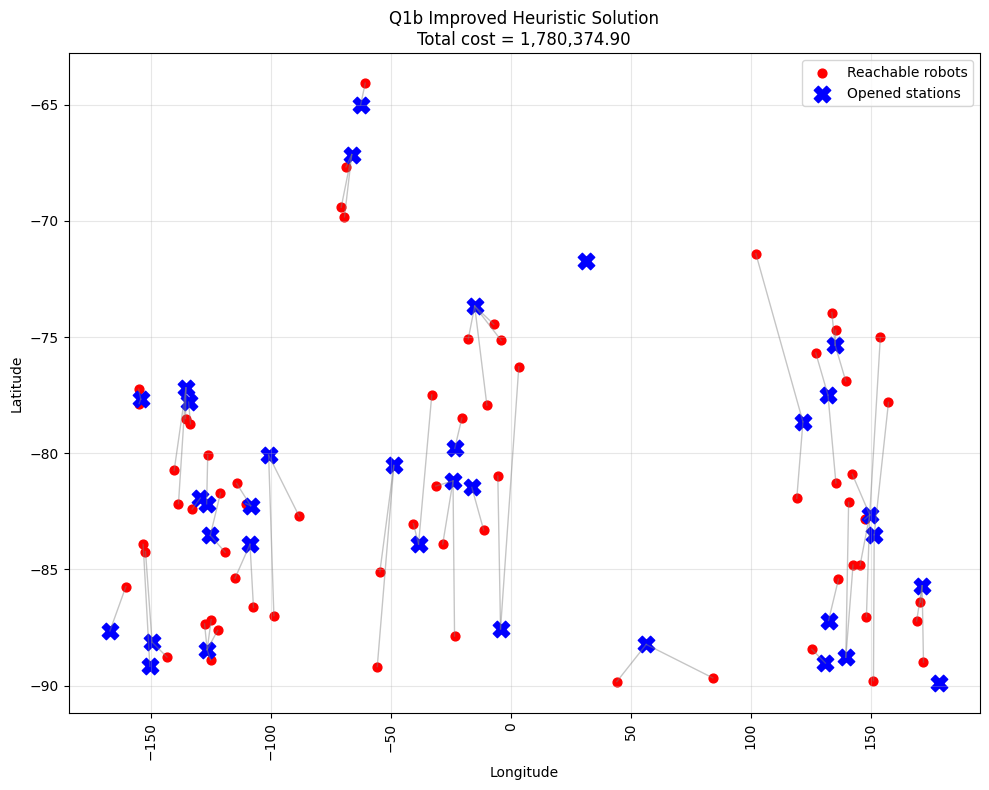

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))

transport_robot_ids = set(
    improved_assignments_df.loc[improved_assignments_df["unreachable"] == 1, "robot_id"]
)

reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

# Plot robots
ax.scatter(
    reachable_robots["longitude"],
    reachable_robots["latitude"],
    c="red",
    s=40,
    label="Reachable robots"
)

if not transport_robots.empty:
    ax.scatter(
        transport_robots["longitude"],
        transport_robots["latitude"],
        c="darkorange",
        s=55,
        label="Transport-needed robots"
    )

# Plot improved stations
ax.scatter(
    improved_stations_df["longitude"],
    improved_stations_df["latitude"],
    c="blue",
    s=140,
    marker="X",
    label="Opened stations"
)

# Plot assignment lines
for _, row in improved_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = improved_stations_df[improved_stations_df["candidate_id"] == row["candidate_id"]].iloc[0]

    line_color = "darkorange" if row["unreachable"] == 1 else "gray"

    ax.plot(
        [robot["longitude"], station["longitude"]],
        [robot["latitude"], station["latitude"]],
        color=line_color,
        alpha=0.45,
        linewidth=1
    )

ax.set_title(f"Q1b Improved Heuristic Solution\nTotal cost = {improved_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


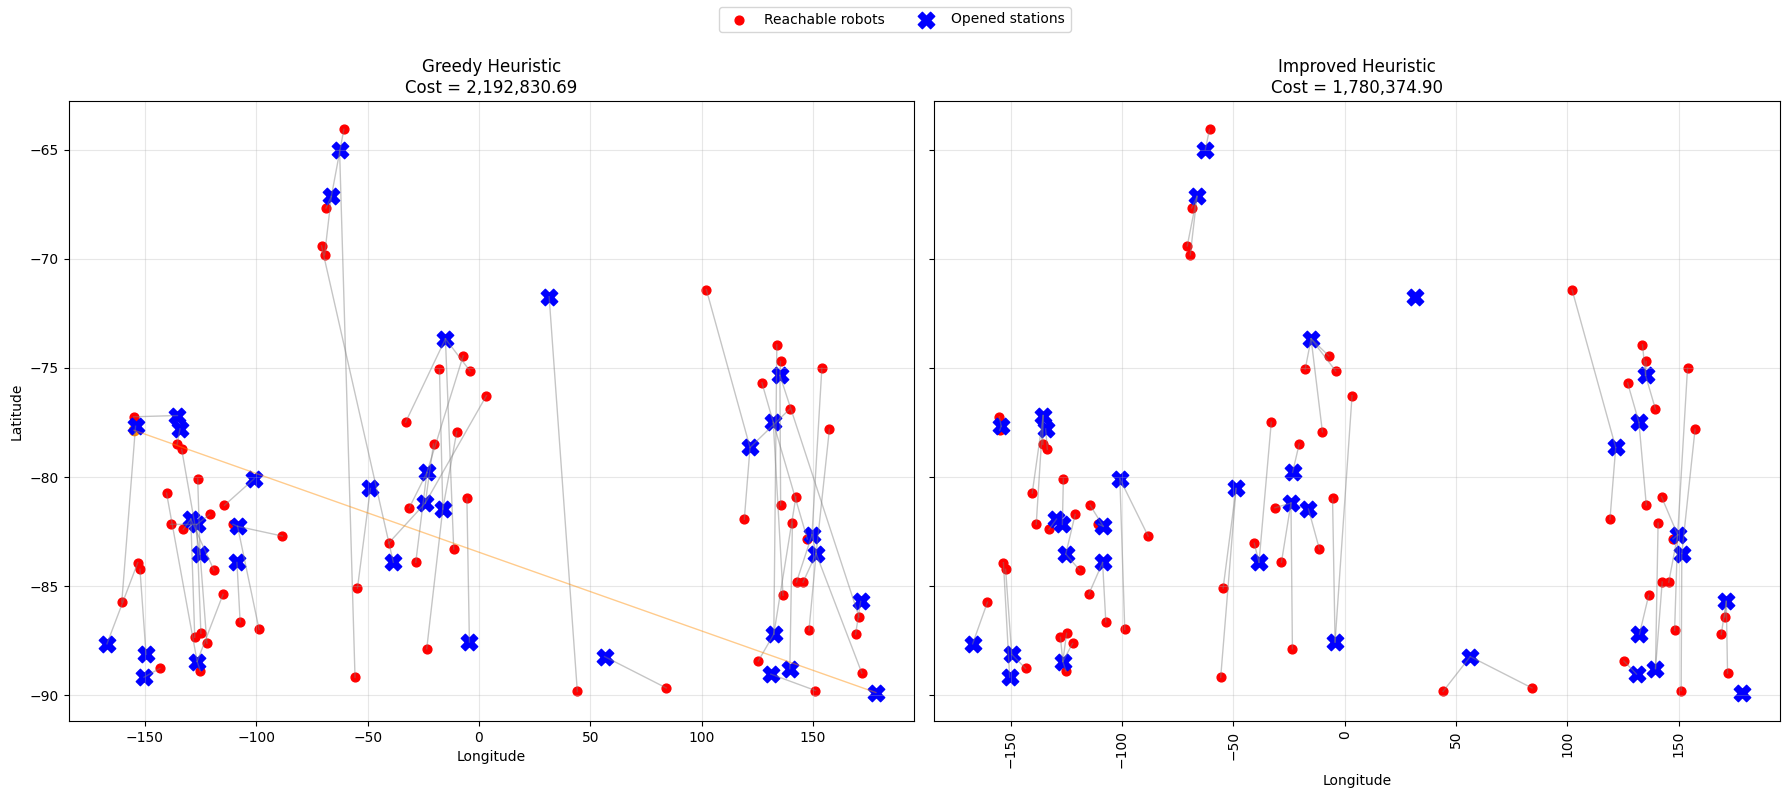

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# Greedy plot
ax = axes[0]
transport_robot_ids = set(
    heuristic_assignments_df.loc[heuristic_assignments_df["unreachable"] == 1, "robot_id"]
)
reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

ax.scatter(reachable_robots["longitude"], reachable_robots["latitude"], c="red", s=40, label="Reachable robots")
if not transport_robots.empty:
    ax.scatter(transport_robots["longitude"], transport_robots["latitude"], c="darkorange", s=55, label="Transport-needed robots")
ax.scatter(heuristic_stations_df["longitude"], heuristic_stations_df["latitude"], c="blue", s=140, marker="X", label="Opened stations")

for _, row in heuristic_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = heuristic_stations_df[heuristic_stations_df["candidate_id"] == row["candidate_id"]].iloc[0]
    line_color = "darkorange" if row["unreachable"] == 1 else "gray"
    ax.plot([robot["longitude"], station["longitude"]], [robot["latitude"], station["latitude"]], color=line_color, alpha=0.45, linewidth=1)

ax.set_title(f"Greedy Heuristic\nCost = {heuristic_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

# Improved plot
ax = axes[1]
transport_robot_ids = set(
    improved_assignments_df.loc[improved_assignments_df["unreachable"] == 1, "robot_id"]
)
reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

ax.scatter(reachable_robots["longitude"], reachable_robots["latitude"], c="red", s=40, label="Reachable robots")
if not transport_robots.empty:
    ax.scatter(transport_robots["longitude"], transport_robots["latitude"], c="darkorange", s=55, label="Transport-needed robots")
ax.scatter(improved_stations_df["longitude"], improved_stations_df["latitude"], c="blue", s=140, marker="X", label="Opened stations")

for _, row in improved_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = improved_stations_df[improved_stations_df["candidate_id"] == row["candidate_id"]].iloc[0]
    line_color = "darkorange" if row["unreachable"] == 1 else "gray"
    ax.plot([robot["longitude"], station["longitude"]], [robot["latitude"], station["latitude"]], color=line_color, alpha=0.45, linewidth=1)

ax.set_title(f"Improved Heuristic\nCost = {improved_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.grid(True, alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.xticks(rotation=90)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Neighbourhood Search

In [21]:
# Helper lookup tables
candidate_xy = candidate_locations.set_index("candidate_id")[["longitude", "latitude"]]
all_candidates = set(candidate_locations["candidate_id"].astype(int).tolist())
robot_ids = robots_subset["robot_id"].astype(int).tolist()

In [22]:
# For set of open candidate station, greedily assign robots to cheapest station and 
# compute total cost of that assignment (including fixed and variable costs)

def evaluate_station_set_greedy(open_station_set, robot_ids, distance_table, candidate_locations,
                                planning_days, m, q, c_b, c_m, c_c, c_h, r_max):
    open_station_set = set(open_station_set)

    if len(open_station_set) == 0: #infeasible if no stations open
        return None

    dt = distance_table[distance_table["candidate_id"].isin(open_station_set)].copy()

    assignment_options = dt.sort_values("assign_cost").reset_index(drop=True) # sort robots by assignment cost

    station_capacity = m * q # max capacity per station
    station_load = {j: 0 for j in open_station_set}
    assigned_robots = set()
    assignments = []

    # Greedily assignment (same as before)
    for _, row in assignment_options.iterrows():
        i = int(row["robot_id"])
        j = int(row["candidate_id"])

        if i in assigned_robots:
            continue

        if station_load[j] >= station_capacity:
            continue

        assignments.append({
            "robot_id": i,
            "candidate_id": j,
            "d_ij": float(row["d_ij"]),
            "range": float(row["range"]),
            "unreachable": int(row["unreachable"]),
            "assign_cost": float(row["assign_cost"])
        })

        assigned_robots.add(i)
        station_load[j] += 1

    if len(assigned_robots) != len(robot_ids):
        return None

    assignments_df = pd.DataFrame(assignments)

    stations_df = pd.DataFrame([
        {
            "candidate_id": j,
            "robots_assigned": station_load[j]
        }
        for j in sorted(open_station_set)
    ]).merge(
        candidate_locations[["candidate_id", "longitude", "latitude"]],
        on="candidate_id",
        how="left"
    )
 
    # calculate required number of chargers
    stations_df["chargers"] = np.ceil(stations_df["robots_assigned"] / q).astype(int)

    if (stations_df["chargers"] > m).any():
        return None

    #calculate costs
    fixed_cost = len(open_station_set) * c_b + stations_df["chargers"].sum() * c_m
    assignment_cost = assignments_df["assign_cost"].sum()
    total_cost = fixed_cost + assignment_cost

    return {
        "open_station_set": open_station_set,
        "total_cost": float(total_cost),
        "stations_df": stations_df,
        "assignments_df": assignments_df
    }


In [23]:
### Evaluate the greedy solution and to prepare for later comparisons
robot_ids = robots_subset["robot_id"].astype(int).tolist()
all_candidates = set(candidate_locations["candidate_id"].astype(int).tolist())

current_station_set = set(heuristic_stations_df["candidate_id"].astype(int).tolist())

current_solution = evaluate_station_set_greedy(
    open_station_set=current_station_set,
    robot_ids=robot_ids,
    distance_table=distance_table,
    candidate_locations=candidate_locations,
    planning_days=planning_days,
    m=m,
    q=q,
    c_b=c_b,
    c_m=c_m,
    c_c=c_c,
    c_h=c_h,
    r_max=r_max
)

print("Starting greedy cost:", current_solution["total_cost"])
print("Starting station set:", sorted(current_solution["open_station_set"]))


Starting greedy cost: 1780324.8643914813
Starting station set: [0, 1, 3, 6, 7, 8, 10, 11, 17, 18, 19, 20, 21, 22, 25, 26, 27, 32, 36, 38, 43, 59, 77, 78, 79, 81, 82, 83, 86, 88, 90, 92, 93, 96]


In [24]:
### Propose swaps between open and closed stations

def generate_swap_neighbours_guided(open_set, candidate_locations, nearest_k=10):
    """
    For each open station, only consider swaps with its nearest closed candidate stations.
    """
    open_set = set(open_set)
    closed_set = all_candidates - open_set

    if not closed_set: # in case no closed stations
        return []

    neighbours = []

    for j_out in open_set: # for each open station
        out_xy = candidate_xy.loc[j_out].to_numpy(dtype=float)  # get coordinates

        # compute distances to all closed stations
        closed_list = []
        for j_in in closed_set:
            in_xy = candidate_xy.loc[j_in].to_numpy(dtype=float)
            dist = np.sqrt(((out_xy - in_xy) ** 2).sum())
            closed_list.append((j_in, dist))

        closed_list.sort(key=lambda x: x[1]) #sort by distance

        # consider swaps with the nearest k closed stations
        for j_in, _ in closed_list[:nearest_k]:
            neighbour = (open_set - {j_out}) | {j_in}
            neighbours.append(("swap", j_out, j_in, neighbour))

    return neighbours


In [25]:
### Propose opening stations near robots with highest current assignment costs

def generate_open_neighbours_guided(current_solution, distance_table, top_robot_count=10, nearest_candidates_per_robot=5):
    """
    Propose opening stations near robots with the highest current assignment costs.
    """
    open_set = current_solution["open_station_set"]
    closed_set = all_candidates - open_set

    if not closed_set:
        return []

    assignments_df = current_solution["assignments_df"].copy()

    # Highest-cost robots first
    high_cost_robots = (
        assignments_df.sort_values("assign_cost", ascending=False)
        .head(top_robot_count)["robot_id"]
        .astype(int)
        .tolist()
    )

    proposed_candidates = set()

    # find closed candidate locations near high assignment-cost robots
    for i in high_cost_robots:
        robot_options = distance_table[
            (distance_table["robot_id"] == i) &
            (distance_table["candidate_id"].isin(closed_set))
        ].sort_values("d_ij")

        # propose the nearest few candidate stations for this robot (avoiding duplicates)
        for j in robot_options.head(nearest_candidates_per_robot)["candidate_id"].astype(int).tolist():
            proposed_candidates.add(j)

    # Propose opening each of these candidate stations
    neighbours = []
    for j_in in proposed_candidates:
        neighbour = open_set | {j_in}
        neighbours.append(("open", None, j_in, neighbour))

    return neighbours


In [26]:
### Propose closing stations whose assigned robots have the lowest average assignment cost

def generate_close_neighbours_guided(current_solution, min_open=1, max_close_candidates=5):

    open_set = current_solution["open_station_set"]

    if len(open_set) <= min_open: # in case we are at minimim number of stations already
        return []

    assignments_df = current_solution["assignments_df"].copy()

    # average assignment cost and number of robots assigned to each open station
    station_scores = (
        assignments_df.groupby("candidate_id")
        .agg(
            avg_assign_cost=("assign_cost", "mean"),
            robots_assigned=("robot_id", "count")
        )
        .reset_index()
        .sort_values(["avg_assign_cost", "robots_assigned"], ascending=[True, True])
    )

    # propose closes
    close_candidates = station_scores.head(max_close_candidates)["candidate_id"].astype(int).tolist()

    # update neighbours with each proposed close
    neighbours = []
    for j_out in close_candidates:
        if len(open_set - {j_out}) >= min_open:
            neighbour = open_set - {j_out}
            neighbours.append(("close", j_out, None, neighbour))

    return neighbours


In [27]:
### Local Search combined function

def find_first_improving_neighbour_greedy(
    current_solution,
    robot_ids,
    distance_table,
    candidate_locations,
    planning_days,
    m,
    q,
    c_b,
    c_m,
    c_c,
    c_h,
    r_max,
    swap_nearest_k=10,
    open_top_robot_count=10,
    open_nearest_candidates_per_robot=5,
    max_close_candidates=5,
    use_open=True,
    use_close=True,
    global_start_time=None,
    global_time_limit_seconds=None
):
    

    current_cost = current_solution["total_cost"]

    neighbour_specs = []

    neighbour_specs += generate_swap_neighbours_guided(
        current_solution["open_station_set"],
        candidate_locations,
        nearest_k=swap_nearest_k
    )

    if use_open:
        neighbour_specs += generate_open_neighbours_guided(
            current_solution,
            distance_table,
            top_robot_count=open_top_robot_count,
            nearest_candidates_per_robot=open_nearest_candidates_per_robot
        )

    if use_close:
        neighbour_specs += generate_close_neighbours_guided(
            current_solution,
            min_open=1,
            max_close_candidates=max_close_candidates
        )

    for move_type, j_out, j_in, neighbour_set in neighbour_specs:
        # Stop if global time limit has been reached
        if global_start_time is not None and global_time_limit_seconds is not None:
            if time.time() - global_start_time >= global_time_limit_seconds:
                print("Global time limit reached during neighbour search.")
                return None, None

        candidate_solution = evaluate_station_set_greedy(
            open_station_set=neighbour_set,
            robot_ids=robot_ids,
            distance_table=distance_table,
            candidate_locations=candidate_locations,
            planning_days=planning_days,
            m=m,
            q=q,
            c_b=c_b,
            c_m=c_m,
            c_c=c_c,
            c_h=c_h,
            r_max=r_max
        )

        if candidate_solution is None:
            continue

        # if new solution is better, return it immediately (first-improvement)
        if candidate_solution["total_cost"] < current_cost:
            return (move_type, j_out, j_in), candidate_solution  

    return None, None


In [28]:
### Run local Search

global_time_limit_seconds = 300   # 5 minutes
start_time = time.time()

local_search_history = [current_solution["total_cost"]]
iteration = 0

while True:
    elapsed = time.time() - start_time

    if elapsed >= global_time_limit_seconds:
        print("Global time limit reached. Local search stops.")
        break

    iteration += 1
    print(f"Local search iteration {iteration}...")
    print(f"Elapsed time: {elapsed:.1f} seconds")

    move, improving_solution = find_first_improving_neighbour_greedy(
        current_solution=current_solution,
        robot_ids=robot_ids,
        distance_table=distance_table,
        candidate_locations=candidate_locations,
        planning_days=planning_days,
        m=m,
        q=q,
        c_b=c_b,
        c_m=c_m,
        c_c=c_c,
        c_h=c_h,
        r_max=r_max,
        swap_nearest_k=10,
        open_top_robot_count=10,
        open_nearest_candidates_per_robot=5,
        max_close_candidates=5,
        use_open=True,
        use_close=True,
        global_start_time=start_time,
        global_time_limit_seconds=global_time_limit_seconds
    )

    if improving_solution is None:
        print("No improving neighbour found or time limit reached. Local search stops.")
        break

    print("Accepted move:", move)
    print("Old cost:", current_solution["total_cost"])
    print("New cost:", improving_solution["total_cost"])

    current_solution = improving_solution
    local_search_history.append(current_solution["total_cost"])

final_ls_solution = current_solution

print("Final local-search cost:", final_ls_solution["total_cost"])
print("Final open stations:", sorted(final_ls_solution["open_station_set"]))
print("Total elapsed time (seconds):", time.time() - start_time)


Local search iteration 1...
Elapsed time: 0.0 seconds
Accepted move: ('swap', 0, 183)
Old cost: 1780324.8643914813
New cost: 1779982.666747566
Local search iteration 2...
Elapsed time: 0.9 seconds
Accepted move: ('swap', 1, 106)
Old cost: 1779982.666747566
New cost: 1779408.2963052292
Local search iteration 3...
Elapsed time: 1.9 seconds
Accepted move: ('swap', 6, 157)
Old cost: 1779408.2963052292
New cost: 1779128.9445630354
Local search iteration 4...
Elapsed time: 4.7 seconds
Accepted move: ('swap', 7, 139)
Old cost: 1779128.9445630354
New cost: 1779018.243808633
Local search iteration 5...
Elapsed time: 7.4 seconds
Accepted move: ('swap', 8, 97)
Old cost: 1779018.243808633
New cost: 1778798.107073788
Local search iteration 6...
Elapsed time: 9.4 seconds
Accepted move: ('swap', 10, 146)
Old cost: 1778798.107073788
New cost: 1778009.7944808512
Local search iteration 7...
Elapsed time: 11.7 seconds
Accepted move: ('swap', 11, 110)
Old cost: 1778009.7944808512
New cost: 1777934.1335492

### Results 3

In [29]:
ls_stations_df = final_ls_solution["stations_df"].copy()
ls_assignments_df = final_ls_solution["assignments_df"].copy()
ls_total_cost = final_ls_solution["total_cost"]

display(ls_stations_df)
display(ls_assignments_df.head(20))


,candidate_id,robots_assigned,longitude,latitude,chargers
0,3,3,56.426577,-88.229542,2
1,18,1,31.520712,-71.740210,1
2,36,2,132.185296,-77.498965,1
3,40,2,-160.427009,-85.737525,1
4,45,2,-121.014543,-81.717837,1
5,47,1,125.425297,-88.435406,1
6,48,1,3.331373,-76.275352,1
7,64,3,-54.570245,-85.092963,2
8,67,3,-17.730380,-75.073075,2
9,77,4,-66.295566,-67.143885,2


,robot_id,candidate_id,d_ij,range,unreachable,assign_cost
0,27,96,0.000000e+00,147.480524,0,4218.735732
1,205,109,5.788654e-01,144.559038,0,4755.339512
2,777,81,2.268851e+00,143.742784,0,5139.546156
3,719,97,0.000000e+00,140.980940,0,5215.121975
4,90,83,1.682829e+00,130.136422,0,7135.564182
5,453,48,4.440892e-16,125.977452,0,7515.156547
6,120,83,4.527326e+00,127.887414,0,7916.398500
7,383,151,4.601655e+00,125.600255,0,8278.414588
8,651,86,6.283674e+00,126.821000,0,8349.127921
9,255,92,1.576821e+00,118.226220,0,8945.147133


In [30]:
ls_buildings_cost = len(final_ls_solution["open_station_set"]) * c_b + ls_stations_df["chargers"].sum() * c_m

ls_assignment_cost = planning_days * (
    c_c * (
        (r_max - ls_assignments_df["range"] + ls_assignments_df["d_ij"]) * (1 - ls_assignments_df["unreachable"])
        + (r_max - ls_assignments_df["range"]) * ls_assignments_df["unreachable"]
    )
).sum()

ls_transport_cost = planning_days * c_h * ls_assignments_df["unreachable"].sum()
ls_total_cost = ls_buildings_cost + ls_assignment_cost + ls_transport_cost
ls_robots_needing_transport = int(ls_assignments_df["unreachable"].sum())

ls_results_summary = pd.DataFrame([
    {
        "Number of robots": len(robot_ids),
        "Number of stations": len(final_ls_solution["open_station_set"]),
        "Number of chargers": int(ls_stations_df["chargers"].sum()),
        "Total cost": ls_total_cost,
        "Assignment cost": ls_assignment_cost,
        "Buildings cost": ls_buildings_cost,
        "Transport cost": ls_transport_cost,
        "Robots needing transport": ls_robots_needing_transport,
        "MIP gap": None,
        "MIP gap (%)": None,
    }
])

ls_results_summary_display = pd.DataFrame([
    {"Metric": "Number of robots", "Value": f"{len(robot_ids):,.0f}"},
    {"Metric": "Number of stations", "Value": f"{len(final_ls_solution['open_station_set']):,.0f}"},
    {"Metric": "Number of chargers", "Value": f"{int(ls_stations_df['chargers'].sum()):,.0f}"},
    {"Metric": "Total cost", "Value": f"{ls_total_cost:,.2f}"},
    {"Metric": "Assignment cost", "Value": f"{ls_assignment_cost:,.2f}"},
    {"Metric": "Buildings cost", "Value": f"{ls_buildings_cost:,.2f}"},
    {"Metric": "Transport cost", "Value": f"{ls_transport_cost:,.2f}"},
    {"Metric": "Robots needing transport", "Value": f"{ls_robots_needing_transport:,.0f}"},
    {"Metric": "MIP gap", "Value": "N/A"},
    {"Metric": "MIP gap (%)", "Value": "N/A"},
])

display(ls_results_summary_display)


,Metric,Value
0,Number of robots,100
1,Number of stations,34
2,Number of chargers,58
3,Total cost,"1,770,398.99"
4,Assignment cost,"1,571,398.99"
5,Buildings cost,"199,000.00"
6,Transport cost,0.00
7,Robots needing transport,0
8,MIP gap,N/A
9,MIP gap (%),N/A


In [31]:
print("Starting greedy heuristic cost:", heuristic_total_cost)
print("Final local-search cost:", ls_total_cost)
print("Absolute improvement:", heuristic_total_cost - ls_total_cost)
print("Percent improvement:", 100 * (heuristic_total_cost - ls_total_cost) / heuristic_total_cost)


Starting greedy heuristic cost: 2192830.689423333
Final local-search cost: 1770398.9939099483
Absolute improvement: 422431.69551338465
Percent improvement: 19.264218507653002


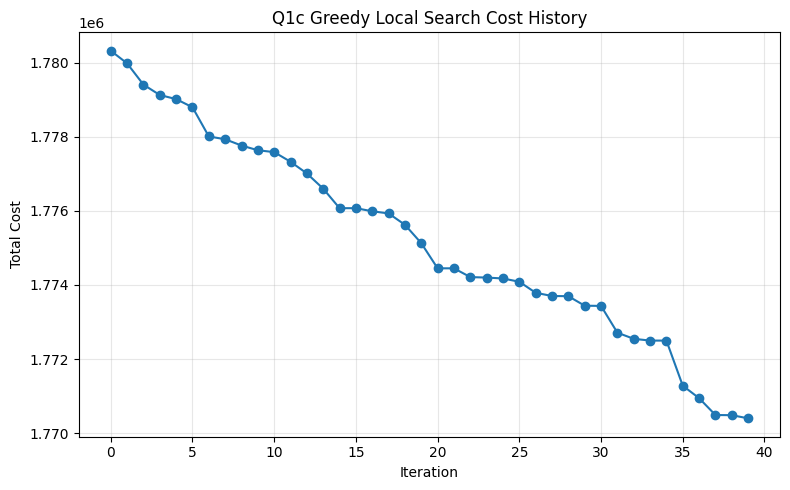

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(local_search_history)), local_search_history, marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("Total Cost")
ax.set_title("Q1c Greedy Local Search Cost History")
ax.grid(True, alpha=0.3)
fig.tight_layout()
#fig.savefig("Graphs/assignments_1c_search_1072.png", dpi=300, bbox_inches="tight")
plt.show()


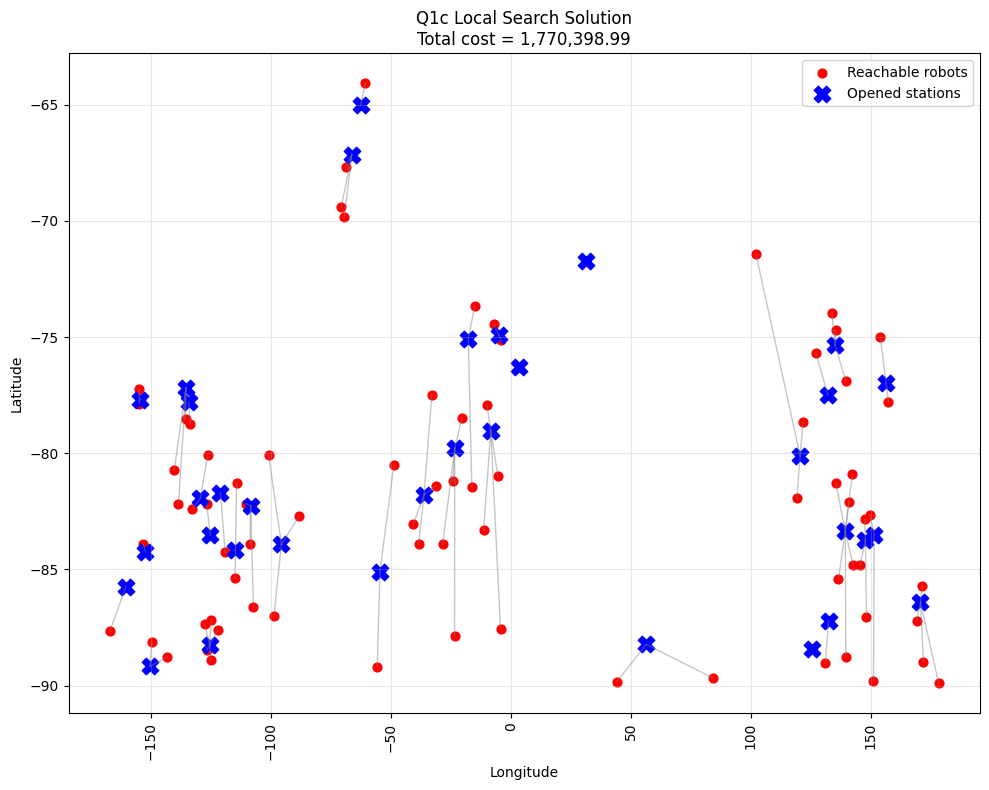

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

transport_robot_ids = set(
    ls_assignments_df.loc[ls_assignments_df["unreachable"] == 1, "robot_id"]
)

reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

ax.scatter(
    reachable_robots["longitude"],
    reachable_robots["latitude"],
    c="red",
    s=40,
    label="Reachable robots"
)

if not transport_robots.empty:
    ax.scatter(
        transport_robots["longitude"],
        transport_robots["latitude"],
        c="darkorange",
        s=55,
        label="Transport-needed robots"
    )

ax.scatter(
    ls_stations_df["longitude"],
    ls_stations_df["latitude"],
    c="blue",
    s=140,
    marker="X",
    label="Opened stations"
)

for _, row in ls_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = ls_stations_df[ls_stations_df["candidate_id"] == row["candidate_id"]].iloc[0]

    line_color = "darkorange" if row["unreachable"] == 1 else "gray"

    ax.plot(
        [robot["longitude"], station["longitude"]],
        [robot["latitude"], station["latitude"]],
        color=line_color,
        alpha=0.45,
        linewidth=1
    )

ax.set_title(f"Q1c Local Search Solution\nTotal cost = {ls_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


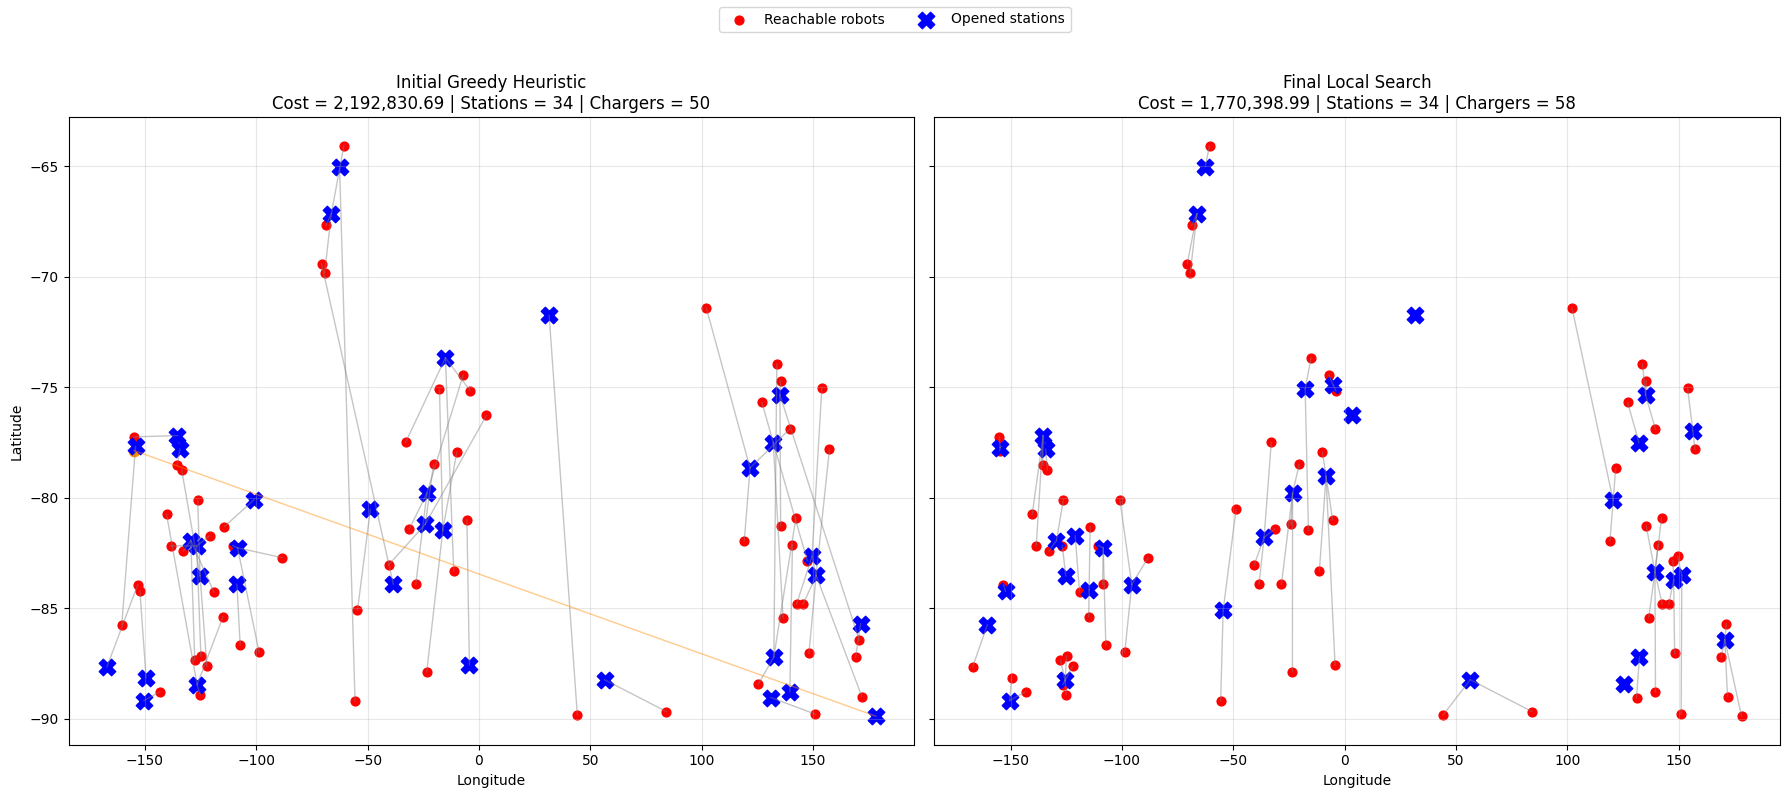

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

def plot_assignment_solution(ax, stations_df, assignments_df, title, total_cost):
    transport_robot_ids = set(
        assignments_df.loc[assignments_df["unreachable"] == 1, "robot_id"]
    )

    reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
    transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

    ax.scatter(
        reachable_robots["longitude"],
        reachable_robots["latitude"],
        c="red",
        s=40,
        label="Reachable robots"
    )

    if not transport_robots.empty:
        ax.scatter(
            transport_robots["longitude"],
            transport_robots["latitude"],
            c="darkorange",
            s=55,
            label="Transport-needed robots"
        )

    ax.scatter(
        stations_df["longitude"],
        stations_df["latitude"],
        c="blue",
        s=140,
        marker="X",
        label="Opened stations"
    )

    for _, row in assignments_df.iterrows():
        robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
        station = stations_df[stations_df["candidate_id"] == row["candidate_id"]].iloc[0]
        line_color = "darkorange" if row["unreachable"] == 1 else "gray"

        ax.plot(
            [robot["longitude"], station["longitude"]],
            [robot["latitude"], station["latitude"]],
            color=line_color,
            alpha=0.45,
            linewidth=1
        )

    ax.set_title(
        f"{title}\n"
        f"Cost = {total_cost:,.2f} | Stations = {len(stations_df)} | Chargers = {int(stations_df['chargers'].sum())}"
    )
    ax.set_xlabel("Longitude")
    ax.grid(True, alpha=0.3)

plot_assignment_solution(
    axes[0],
    heuristic_stations_df,
    heuristic_assignments_df,
    "Initial Greedy Heuristic",
    heuristic_total_cost
)

plot_assignment_solution(
    axes[1],
    ls_stations_df,
    ls_assignments_df,
    "Final Local Search",
    ls_total_cost
)

axes[0].set_ylabel("Latitude")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.93])
#fig.savefig("Graphs/assignments_1c_compare_greedy_1072.png", dpi=300, bbox_inches="tight")
plt.show()


### Optimisation MIP

In [35]:
# Resolve the same fixed-station MILP form as before, using the final local-search open stations.
# Station locations remain fixed at their candidate locations; this re-optimises assignments and chargers.

J_location = sorted(final_ls_solution["open_station_set"])

loc_range_lookup = robots_subset.set_index("robot_id")["range"].to_dict()

loc_distance_lookup = {
    (int(row.robot_id), int(row.candidate_id)): float(row.d_ij)
    for row in distance_table.itertuples(index=False)
    if int(row.candidate_id) in J_location
}

loc_unreachable_lookup = {
    (int(row.robot_id), int(row.candidate_id)): int(row.unreachable)
    for row in distance_table.itertuples(index=False)
    if int(row.candidate_id) in J_location
}

loc_model = pyo.ConcreteModel()
loc_model.I = pyo.Set(initialize=robot_ids)
loc_model.J = pyo.Set(initialize=J_location)

loc_model.r = pyo.Param(loc_model.I, initialize=loc_range_lookup)
loc_model.d = pyo.Param(loc_model.I, loc_model.J, initialize=loc_distance_lookup)
loc_model.unreachable = pyo.Param(
    loc_model.I,
    loc_model.J,
    initialize=loc_unreachable_lookup,
    within=pyo.Binary
)


# Decision variables
loc_model.z = pyo.Var(loc_model.J, domain=pyo.NonNegativeIntegers)
loc_model.x = pyo.Var(loc_model.I, loc_model.J, domain=pyo.Binary)

# Each robot assigned to exactly one opened station
def loc_assign_once_rule(model, i):
    return sum(model.x[i, j] for j in model.J) == 1
loc_model.assign_once = pyo.Constraint(loc_model.I, rule=loc_assign_once_rule)

# Capacity at each opened station
def loc_charger_capacity_rule(model, j):
    return sum(model.x[i, j] for i in model.I) <= q * model.z[j]
loc_model.charger_capacity = pyo.Constraint(loc_model.J, rule=loc_charger_capacity_rule)

# Charger limit at each opened station
def loc_charger_limit_rule(model, j):
    return model.z[j] <= m
loc_model.charger_limit = pyo.Constraint(loc_model.J, rule=loc_charger_limit_rule)

# At least one charger at each opened station
def loc_min_charger_rule(model, j):
    return model.z[j] >= 1
loc_model.min_charger = pyo.Constraint(loc_model.J, rule=loc_min_charger_rule)

# Objective over fixed open stations
def loc_objective_rule(model):
    fixed_cost = len(J_location) * c_b + sum(c_m * model.z[j] for j in model.J)
    charging_cost = planning_days * sum(
        c_c * (
            (r_max - model.r[i] + model.d[i, j]) * (1 - model.unreachable[i, j])
            + (r_max - model.r[i]) * model.unreachable[i, j]
        ) * model.x[i, j]
        for i in model.I for j in model.J
    )
    transport_cost = planning_days * sum(c_h * model.unreachable[i, j] * model.x[i, j] for i in model.I for j in model.J)
    return fixed_cost + charging_cost + transport_cost

loc_model.obj = pyo.Objective(rule=loc_objective_rule, sense=pyo.minimize)

# Warm start from the final local-search solution.
ls_station_lookup = ls_stations_df.set_index("candidate_id")
ls_assignment_lookup = ls_assignments_df.set_index("robot_id")

for j in loc_model.J:
    loc_model.z[j].value = int(ls_station_lookup.loc[j, "chargers"])

for i in loc_model.I:
    assigned_j = int(ls_assignment_lookup.loc[i, "candidate_id"])
    for j in loc_model.J:
        loc_model.x[i, j].value = 1 if j == assigned_j else 0

loc_solver = pyo.SolverFactory("gurobi")
if not loc_solver.available(False):
    raise RuntimeError("Gurobi is not available in this environment.")

fig
#loc_solver.options["MIPGap"] = 0.01

loc_results = loc_solver.solve(loc_model, tee=True)

print("Status:", loc_results.solver.status)
print("Termination:", loc_results.solver.termination_condition)
print("Resolved MIP objective value:", pyo.value(loc_model.obj))


Read LP format model from file C:\Users\asher\AppData\Local\Temp\tmplcunjzgo.pyomo.lp
Reading time = 0.25 seconds
x1: 202 rows, 3435 columns, 6902 nonzeros
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 202 rows, 3435 columns and 6902 nonzeros (Min)
Model fingerprint: 0xc5a2afae
Model has 3435 linear objective coefficients
Variable types: 1 continuous, 3434 integer (3400 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [5e+02, 4e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 8e+00]
Found heuristic solution: objective 2.557879e+07
Presolve removed 68 rows and 1 columns
Presolve time: 0.06s
Presolved: 134 rows, 3434 columns, 6834 nonzeros
Variable types: 0 continuous, 3434 integer (3400 binary)

Root relaxation: obj

### Results 4

In [36]:
loc_stations_df = pd.DataFrame([
    {
        "candidate_id": j,
        "chargers": int(round(pyo.value(loc_model.z[j])))
    }
    for j in loc_model.J
]).merge(
    candidate_locations[["candidate_id", "longitude", "latitude"]],
    on="candidate_id",
    how="left"
)

loc_assignments_df = pd.DataFrame([
    {
        "robot_id": i,
        "candidate_id": j,
        "distance": float(pyo.value(loc_model.d[i, j])),
        "range": pyo.value(loc_model.r[i]),
        "unreachable": int(pyo.value(loc_model.unreachable[i, j]))
    }
    for i in loc_model.I
    for j in loc_model.J
    if pyo.value(loc_model.x[i, j]) > 0.5
])

display(loc_stations_df)
display(loc_assignments_df.head(20))


,candidate_id,chargers,longitude,latitude
0,3,2,56.426577,-88.229542
1,18,1,31.520712,-71.740210
2,36,1,132.185296,-77.498965
3,40,1,-160.427009,-85.737525
4,45,1,-121.014543,-81.717837
5,47,1,125.425297,-88.435406
6,48,1,3.331373,-76.275352
7,64,2,-54.570245,-85.092963
8,67,1,-17.730380,-75.073075
9,77,2,-66.295566,-67.143885


,robot_id,candidate_id,distance,range,unreachable
0,120,83,4.527326,127.887414,0
1,552,36,0.000000,60.391929,0
2,90,83,1.682829,130.136422,0
3,973,90,2.149959,65.957089,0
4,667,106,2.463889,41.008548,0
5,314,67,3.016505,50.515308,0
6,181,123,1.227375,30.119770,0
7,119,93,7.161651,106.700303,0
8,49,102,0.730891,25.688149,0
9,101,96,6.065589,28.071125,0


In [37]:
def _as_float(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None

loc_buildings_cost = len(J_location) * c_b + sum(c_m * pyo.value(loc_model.z[j]) for j in loc_model.J)
loc_assignment_cost = planning_days * sum(
    c_c * (
        (r_max - pyo.value(loc_model.r[i]) + pyo.value(loc_model.d[i, j])) * (1 - pyo.value(loc_model.unreachable[i, j]))
        + (r_max - pyo.value(loc_model.r[i])) * pyo.value(loc_model.unreachable[i, j])
    ) * pyo.value(loc_model.x[i, j])
    for i in loc_model.I for j in loc_model.J
)
loc_transport_cost = planning_days * sum(c_h * pyo.value(loc_model.unreachable[i, j]) * pyo.value(loc_model.x[i, j]) for i in loc_model.I for j in loc_model.J)
loc_total_cost = pyo.value(loc_model.obj)
loc_robots_needing_transport = int(loc_assignments_df["unreachable"].sum()) if not loc_assignments_df.empty else 0

lower_bound = _as_float(getattr(loc_results.problem, "lower_bound", None))
upper_bound = _as_float(getattr(loc_results.problem, "upper_bound", None))
loc_mip_gap = _as_float(getattr(loc_results.solver, "mip_gap", None))

if loc_mip_gap is None:
    loc_mip_gap = _as_float(getattr(loc_results.solver, "gap", None))

if loc_mip_gap is None and lower_bound is not None and upper_bound is not None:
    loc_mip_gap = abs(upper_bound - lower_bound) / max(abs(upper_bound), 1e-9)

loc_results_summary = pd.DataFrame([
    {
        "Number of robots": len(loc_model.I),
        "Number of stations": len(loc_model.J),
        "Number of chargers": int(round(sum(pyo.value(loc_model.z[j]) for j in loc_model.J))),
        "Total cost": loc_total_cost,
        "Assignment cost": loc_assignment_cost,
        "Buildings cost": loc_buildings_cost,
        "Transport cost": loc_transport_cost,
        "Robots needing transport": loc_robots_needing_transport,
        "MIP gap": loc_mip_gap,
        "MIP gap (%)": None if loc_mip_gap is None else 100 * loc_mip_gap,
    }
])

loc_results_summary_display = pd.DataFrame([
    {"Metric": "Number of robots", "Value": f"{len(loc_model.I):,.0f}"},
    {"Metric": "Number of stations", "Value": f"{len(loc_model.J):,.0f}"},
    {"Metric": "Number of chargers", "Value": f"{int(round(sum(pyo.value(loc_model.z[j]) for j in loc_model.J))):,.0f}"},
    {"Metric": "Total cost", "Value": f"{loc_total_cost:,.2f}"},
    {"Metric": "Assignment cost", "Value": f"{loc_assignment_cost:,.2f}"},
    {"Metric": "Buildings cost", "Value": f"{loc_buildings_cost:,.2f}"},
    {"Metric": "Transport cost", "Value": f"{loc_transport_cost:,.2f}"},
    {"Metric": "Robots needing transport", "Value": f"{loc_robots_needing_transport:,.0f}"},
    {"Metric": "MIP gap", "Value": "N/A" if loc_mip_gap is None else f"{loc_mip_gap:.6f}"},
    {"Metric": "MIP gap (%)", "Value": "N/A" if loc_mip_gap is None else f"{100 * loc_mip_gap:.4f}%"},
])

display(loc_results_summary_display)


,Metric,Value
0,Number of robots,100
1,Number of stations,34
2,Number of chargers,55
3,Total cost,"1,769,451.29"
4,Assignment cost,"1,571,951.29"
5,Buildings cost,"197,500.00"
6,Transport cost,0.00
7,Robots needing transport,0
8,MIP gap,0.000094
9,MIP gap (%),0.0094%


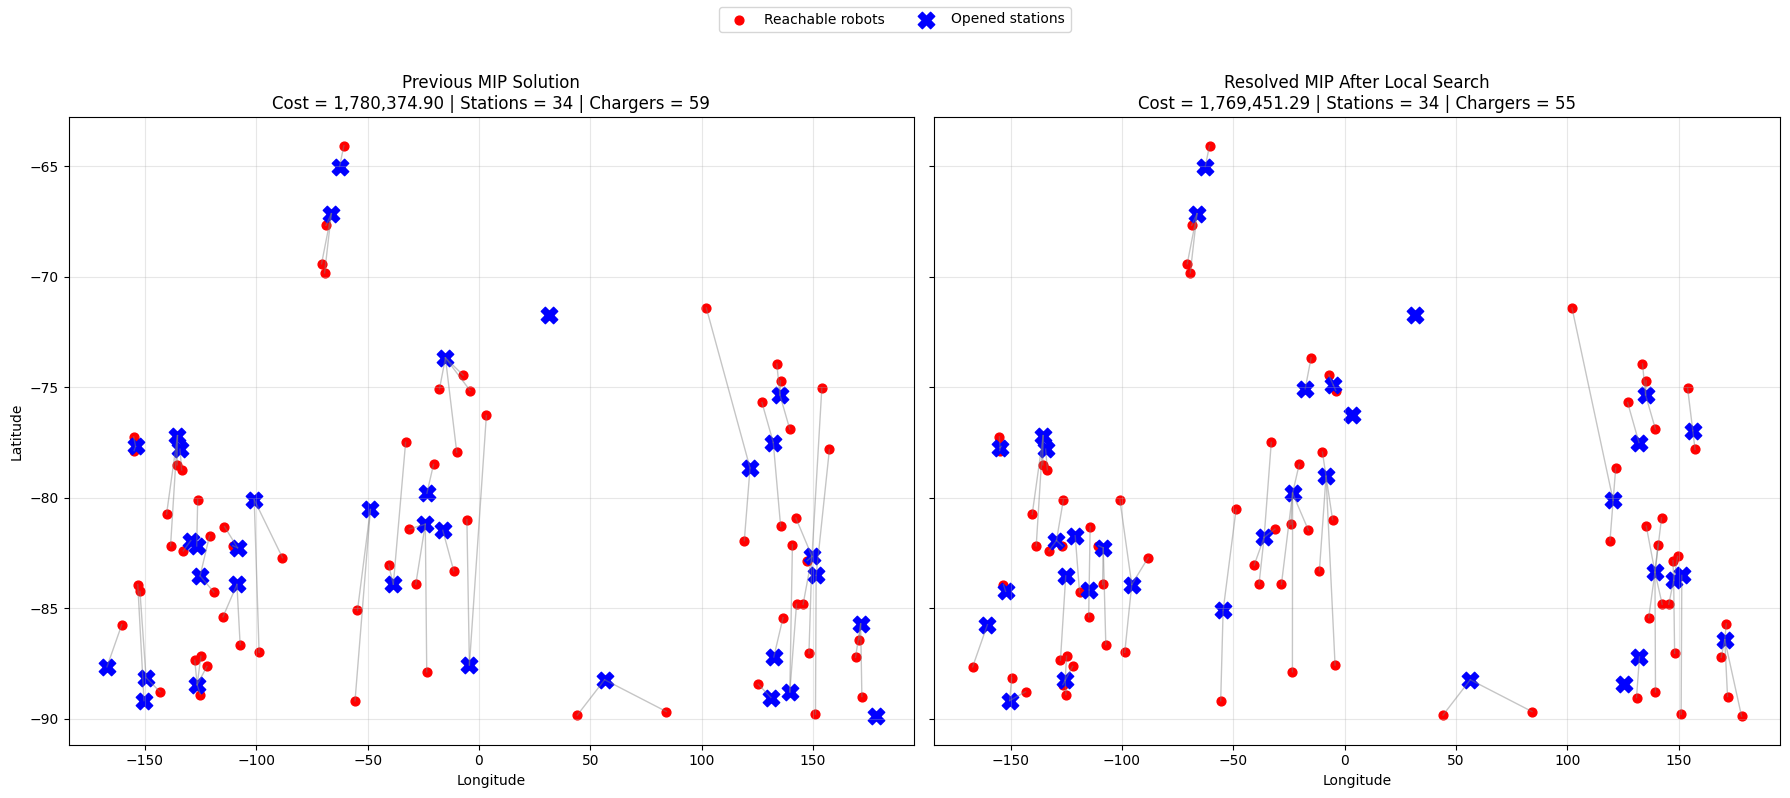

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

plot_assignment_solution(axes[0], improved_stations_df, improved_assignments_df, "Previous MIP Solution", improved_total_cost)
plot_assignment_solution(axes[1], loc_stations_df, loc_assignments_df, "Resolved MIP After Local Search", loc_total_cost)

axes[0].set_ylabel("Latitude")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.93])
#fig.savefig("Graphs/assignments_1c_compare_MIP_1072.png", dpi=300, bbox_inches="tight")
plt.show()
